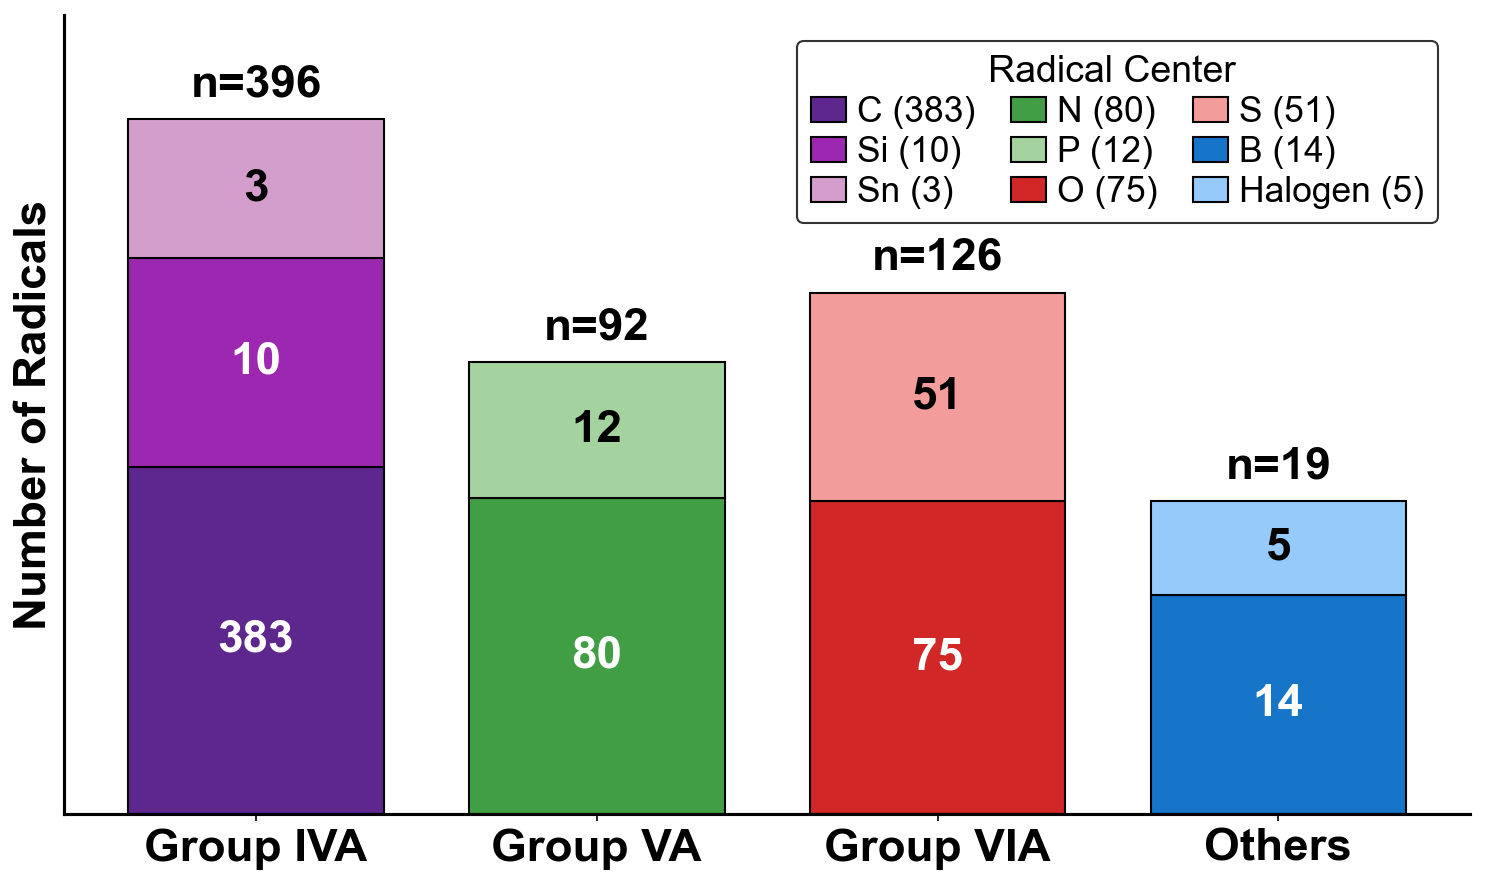

In [ ]:
import matplotlib.pyplot as plt

# Set global font
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

# X-axis labels
groups = ['Group IVA', 'Group VA', 'Group VIA', 'Others']

# Actual totals
actual_totals = [396, 92, 126, 19] 

# Visual total heights 
visual_totals = [100, 65, 75, 45] 

# Data dictionary (matching colors from reference figure)
data = {
    'Group IVA': {
        'elements': ['C', 'Si', 'Sn'],
        'actual': [383, 10, 3],
        'visual_ratio': [5, 3, 2], 
        # Deep purple, medium purple, light purple
        'colors': ['#5E278E', '#9C27B0', '#D49ECC'], 
        'text_colors': ['white', 'white', 'black']
    },
    'Group VA': {
        'elements': ['N', 'P'],
        'actual': [80, 12],
        'visual_ratio': [7, 3],
        # Dark green, light green
        'colors': ['#419E45', '#A5D39F'], 
        'text_colors': ['white', 'black']
    },
    'Group VIA': {
        'elements': ['O', 'S'],
        'actual': [75, 51],
        'visual_ratio': [6, 4], 
        # Dark red, light red (pink)
        'colors': ['#D12727', '#F29C9C'], 
        'text_colors': ['white', 'black']
    },
    'Others': {
        'elements': ['B', 'Halogen'],
        'actual': [14, 5],
        'visual_ratio': [7, 3],
        # Dark blue, light blue
        'colors': ['#1674C9', '#96CAFA'], 
        'text_colors': ['white', 'black']
    }
}

fig, ax = plt.subplots(figsize=(10, 6), dpi=150) 

for i, group in enumerate(groups):
    group_data = data[group]
    
    ratio_sum = sum(group_data['visual_ratio'])
    visual_heights = [visual_totals[i] * (r / ratio_sum) for r in group_data['visual_ratio']]
    
    bottom = 0
    for j in range(len(group_data['elements'])):
        v_height = visual_heights[j]
        a_value = group_data['actual'][j]
        color = group_data['colors'][j]
        text_color = group_data['text_colors'][j]
        element_name = f"{group_data['elements'][j]} ({a_value})"
        
        # Plot stacked bars with black borders
        ax.bar(i, v_height, bottom=bottom, color=color, 
               edgecolor='black', linewidth=1.0, width=0.75, label=element_name)
        
        # Add actual counts inside the bars
        ax.text(i, bottom + v_height / 2, str(a_value), 
                ha='center', va='center', color=text_color, fontweight='bold', fontsize=22)
        
        bottom += v_height

    # Add total count (n=xxx) on top
    ax.text(i, visual_totals[i] + 2, f'n={actual_totals[i]}', 
            ha='center', va='bottom', fontweight='bold', fontsize=22)

# Set Y-axis limit to 115
ax.set_ylim(0, 115) 

# Axes formatting
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, fontweight='bold', fontsize=22)
ax.set_ylabel('Number of Radicals', fontweight='bold', fontsize=22)

# Hide Y-axis numbers/ticks
ax.set_yticks([]) 

# Spine formatting
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Legend formatting
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, 
          title='Radical Center ', 
          loc='upper right',           
          bbox_to_anchor=(0.99, 0.99), 
          ncol=3,                     
          columnspacing=1,          
          frameon=True, 
          facecolor='white',
          edgecolor='black',
          fontsize=17,                
          title_fontsize=18,          
          labelspacing=0.2,           
          handletextpad=0.3,          
          handlelength=1)           

plt.tight_layout()
plt.show()